<a href="https://colab.research.google.com/github/apranav22/bayesian_nmor/blob/main/toy_bayesian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##!pip install cupy-cuda11x

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 22.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
import sys
from google.colab import drive
drive.mount('/content/drive')
package_path = '/content/Libraries'
#os.symlink('/content/drive/MyDrive/Colab_Notebooks/Libraries', package_path)
sys.path.insert(0, package_path)

Mounted at /content/drive


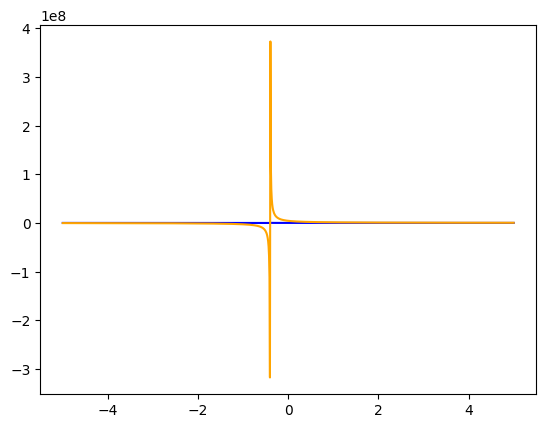

In [ ]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

global tou, delta, k2, transit_rate, lo

#spontaneous emission rate ~ 10^7 Hz
tou = 10**7
#detuning
delta = 0.5*tou
#saturation parameter
k2= 5
#transit rate
transit_rate = 0.01*tou
#unsaturated absorption length
lo = 0.001

def alpha_th(B_tot):
    #gyromagnetic ratio ~ 10^6 Hz/Guass, larmor freq
    gyro = 0.00001
    omega_l = gyro*(B_tot)
    D = (8*(omega_l**2)*((32*(tou**2)*(k2+3)*((omega_l**2)+(delta**2)))+(192*(((delta**2) - (omega_l**2))**2))+((tou**4)*(k2+2)*(k2+6))))
    +(2*(transit_rate**2)*(((tou**2)*((2*k2)+3))+(12*(delta**2)))*(((tou**2)*((k2+2)**2))+(16*(delta**2))))
    alpha_th = (-6*tou*omega_l*((8*(omega_l**2)*((8*(omega_l**2))+((tou**2)*(k2+2))-(8*(delta**2))))
    +(transit_rate*((4*transit_rate*((tou**2)-((2*delta)**2)))-((tou**3)*k2*(k2+2)))))/D)
    return lo*alpha_th


def alpha_exp(alpha_th, sigma):
    return lo*(alpha_th + np.random.normal(0, sigma, size=alpha_th.shape))

# Dispersive Lorentzian Model
'''def alpha_th(B_total, Gamma=1.0):
    # Simplified dispersive Lorentzian form
    return B_total / (B_total**2 + Gamma**2)'''



B_unk = 0.4
gamma = 0.02
sigma = 0.1

B_bias = np.linspace(-5, 5, 1000)
B_tot = B_unk + B_bias

alpha_vals = alpha_th(B_tot)


alpha_exp_vals = alpha_exp(alpha_vals, sigma)
plt.figure()
plt.plot(B_bias, alpha_exp_vals, color ='blue')
plt.plot(B_bias, alpha_vals, color = 'orange')


In [ ]:
import numpy as np
import cupy as cp
from scipy.stats import norm
from scipy.integrate import simpson
import os

global tou, delta, k2, transit_rate, lo
#spontaneous emission rate
tou = 1
#detuning
delta = 0.1
#saturation parameter
k2= 5
#transit rate
transit_rate = 0.01*tou
#unsaturated absorption length
lo = 1

def alpha_theory(B_tot):
    #gyromagnetic ratio, larmor freq
    gyro = 1
    omega_l = gyro*(B_tot)
    D = (8*(omega_l**2)*((32*(tou**2)*(k2+3)*((omega_l**2)+(delta**2)))+(192*(((delta**2) - (omega_l**2))**2))+((tou**4)*(k2+2)*(k2+6))))
    +(2*(transit_rate**2)*(((tou**2)*((2*k2)+3))+(12*(delta**2)))*(((tou**2)*((k2+2)**2))+(16*(delta**2))))
    alpha_th = (-6*tou*omega_l*((8*(omega_l**2)*((8*(omega_l**2))+((tou**2)*(k2+2))-(8*(delta**2))))
    +(transit_rate*((4*transit_rate*((tou**2)-((2*delta)**2)))-((tou**3)*k2*(k2+2)))))/D/lo)
    return alpha_th

'''# Dispersive Lorentzian Model
def alpha_theory(B_total, Gamma=1.0):
    # Simplified dispersive Lorentzian form
    return B_total / (B_total**2 + Gamma**2)'''


#Likelihood for a measurement
'''def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total, Gamma)
    return norm.pdf(alpha_meas, loc=alpha_exp, scale=sigma)'''

#likelihood  for cp and also actual expression
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    prefactor = 1.0 / (sigma * cp.sqrt(2 * np.pi))
    exponent = -((alpha_meas - alpha_exp)**2) / (2 * sigma**2)

    return prefactor * cp.exp(exponent)

def simpson_gpu(y, x):
    """Bro why is there no GPU implemetation of simpsons? :_("""
    dx = x[1] - x[0]
    n = len(x)
    if n % 2 == 0:
        x = x[:-1]
        y = y[..., :-1]

    # Simpson's 1/3 rule: dx/3 * (y_0 + 4y_1 + 2y_2 + ... + 4y_{n-1} + y_n)
    return dx / 3. * cp.sum(y[..., 0:-1:2] + 4.*y[..., 1::2] + y[..., 2::2], axis=-1)


# Posterior update
def update_posterior(prior, measurements, B_grid, B_bias, sigma=0.05):
    post = prior.copy()
    for alpha_meas in measurements:
        # FASTER: Calculate likelihood for all B_grid points at once
        L = likelihood(alpha_meas, B_grid, B_bias, sigma)
        post *= L

    # normalize
    post_sum = simpson_gpu(post, B_grid)
    if post_sum > 1e-12:
        post /= post_sum
    else:
        # Handle cases where the posterior is effectively zero everywhere
        post = cp.ones_like(B_grid) / (B_grid.max() - B_grid.min())
    return post

# KL Divergence Utility
def expected_KL(B_bias, prior, B_grid, sigma=0.1, n_samples=100):
    # Sample possible outcomes (FIXME: this range is still hardcoded)
    alphas = cp.linspace(-1.5, 1.5, n_samples)

    # Shape: (n_samples, n_grid)
    alpha_grid, B_grid_2d = cp.meshgrid(alphas, B_grid, indexing='ij')
    L_matrix = likelihood(alpha_grid, B_grid_2d, B_bias, sigma)

    # Calculate marginal likelihood P(alpha|B_bias) for all alphas at once
    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson_gpu(integrand_P_alpha, B_grid)

    # Calculate KL divergence for each alpha
    # The posterior for each alpha is integrand_P_alpha
    norm_factors = P_alpha

    # To avoid division by zero for alphas with zero probability
    valid_indices = norm_factors>=0
    if not cp.any(valid_indices):
        return 0.0

    epsilon = 1e-15

    post_matrix = integrand_P_alpha[valid_indices] / norm_factors[valid_indices, cp.newaxis] #what does np.newaxis? FIXME

    ratio = post_matrix / (prior[cp.newaxis, :] + epsilon)
    ratio[ratio <= 0] = epsilon
    log_ratio = cp.log(ratio)

    # Handle -inf * 0 cases
    KL_integrand = post_matrix * log_ratio
    KL_integrand[cp.isnan(KL_integrand)] = 0.0
    KL_vals = simpson_gpu(post_matrix * cp.log(ratio), B_grid)

    # Calculate the final expected value
    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / cp.sum(P_alpha[valid_indices])

    return float(expected_KL_val)


# Adaptive Bayesian Experiment Loop
def run_experiment(
    N_exp=5, B_true=0.2, sigma=0.05, B_range=(-1, 1), n_grid=1000, candidates = cp.linspace(-1, 1, 5000), Test = 0, Gamma = 1.0
):  # FIXME: Why is b_range (-1,1)?

    # Step 1: initialize prior
    B_grid = cp.linspace(B_range[0], B_range[1], n_grid)
    prior = cp.ones_like(B_grid) / (B_range[1] - B_range[0])  # uniform prior
    B_biases = []
    Expected_KL =  []
    posteriors = [prior]

    for _ in range(N_exp):
        # Step 2: choose bias by maximizing expected KL # FIXME
         # FIXME range of candidates is arbitrary
        util_vals = cp.array([expected_KL(b, prior, B_grid, sigma) for b in candidates])
        B_bias = candidates[cp.argmax(util_vals)]
        B_biases.append(B_bias)
        Expected_KL.append(float(util_vals[cp.argmax(util_vals)]))

        #code block which creates and saves plots of expected KL vs B_bias for each experiment within directory "Experiment i" - need to do the cp to np conversion
        #to use matplotlib ig - FIXME
        new_dir = "/content/drive/MyDrive/Colab_Notebooks/UGP_2/Test_{Test}".format(Test=Test)
        os.makedirs(new_dir, exist_ok=True)
        save_path = os.path.join(new_dir, f'Expected_KL_vs_B_bias_Experment{_+1}.png')
        plt.figure(figsize=(6, 4))
        plt.plot(candidates.get(), util_vals.get(), label="Expected KL divergence as a function of B_Bias")
        plt.xlabel("B_bias")
        plt.ylabel("Expected KL Divergence")
        plt.title("Expected KL vs B_bias for Experiment {i}".format(i=_+1))
        plt.savefig(save_path)


        # Step 3: generate synthetic measurement
        B_total = B_true + B_bias
        alpha_true = alpha_theory(B_total)
        alpha_meas = cp.random.normal(alpha_true, sigma, size=5)  # 5 samples -> Integration time FIXME
        # Step 4: update posterior
        posterior = update_posterior(prior, alpha_meas, B_grid, B_bias, sigma)
        posteriors.append(posterior)
        prior = posterior
    final_posteriors_cpu = [p.get() for p in posteriors]
    final_biases_cpu = B_biases#.get()
    final_B_grid = B_grid.get()

    return final_B_grid, final_posteriors_cpu, final_biases_cpu, Expected_KL

def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = simpson(B_grid * posterior, B_grid)

    # Mode
    mode_index = np.argmax(posterior)
    mode = B_grid[mode_index]

     # Variance
    variance = simpson(((B_grid - mean)**2) * posterior, B_grid)

    return mean, mode, variance

Test 0

In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=25, B_true=B_true, Gamma=1.0, sigma=0.2, B_range=(-1, 1), n_grid=5000, candidates = cp.linspace(-1, 1, 5000), Test = 0, Gamma = 0.01
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles = line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final,mode_final,variance_final = calculate_summary_stats(final_posterior, B_grid)
print('Mean:',mean_final,', Mode:', mode_final,', Varianc:', variance_final)
for i in range(len(biases)):
    print(biases[i],':', xpected_kl[i],'\n')

Test 1

/tmp/ipython-input-4188532084.py:145: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


Final posterior area (should be ~1): 1.000000


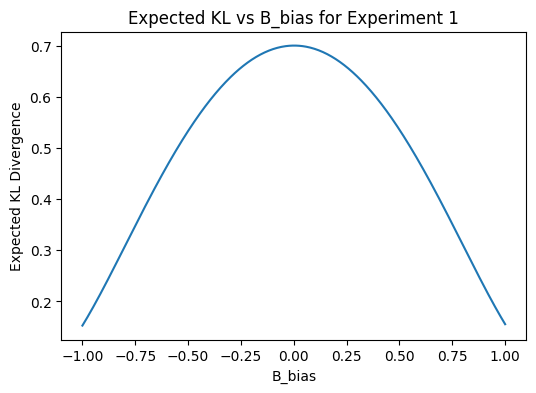

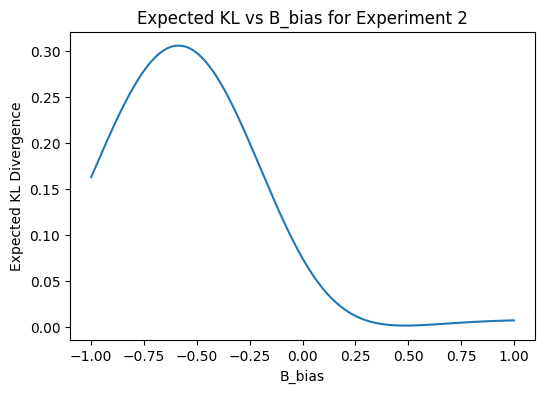

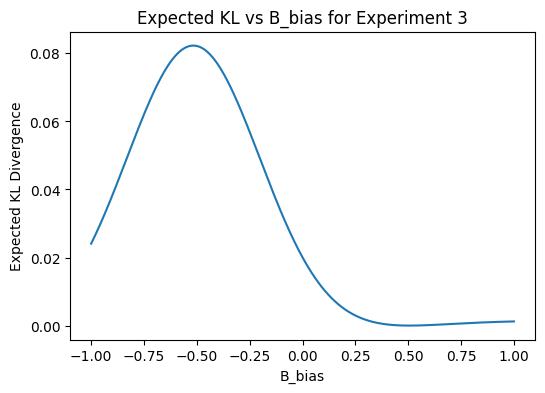

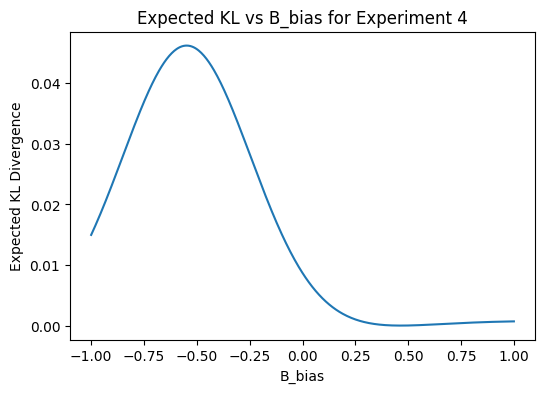

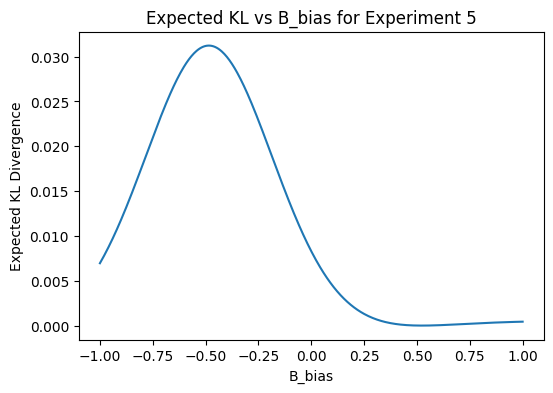

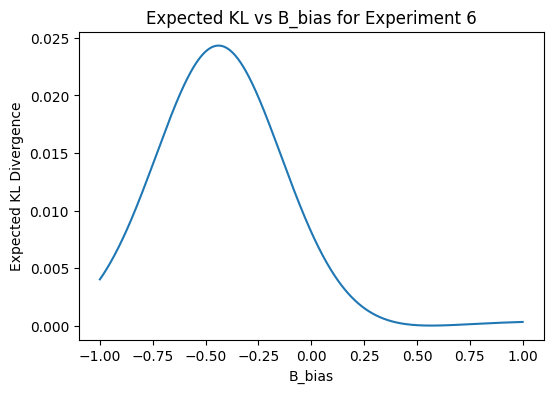

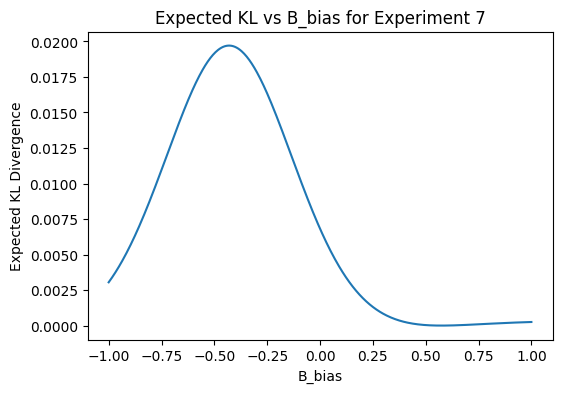

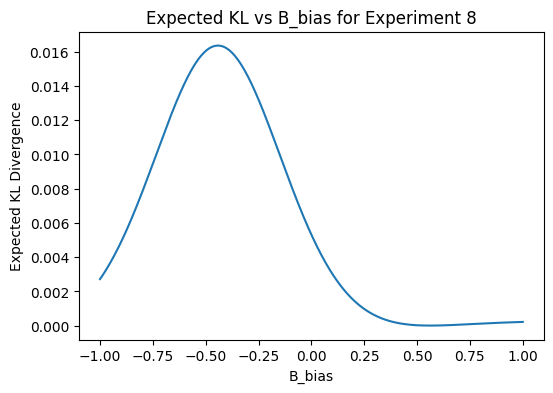

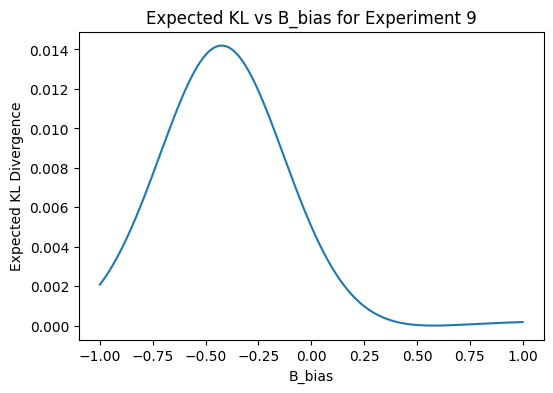

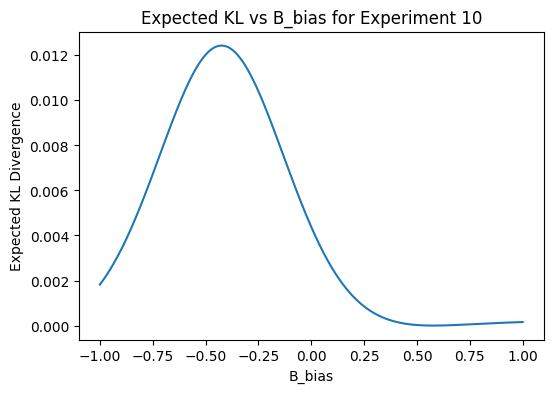

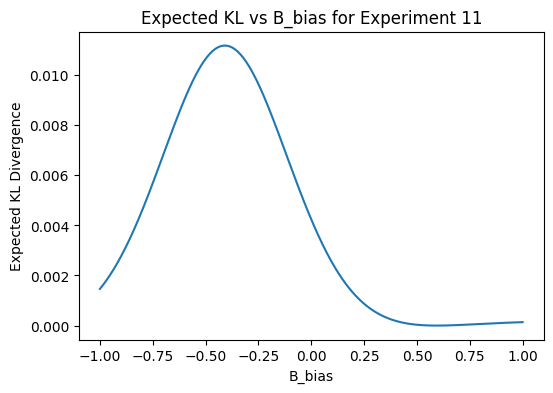

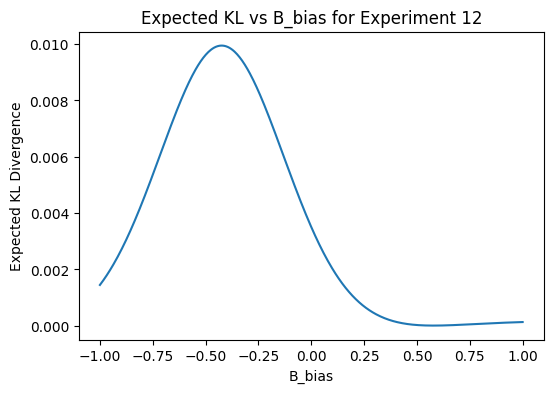

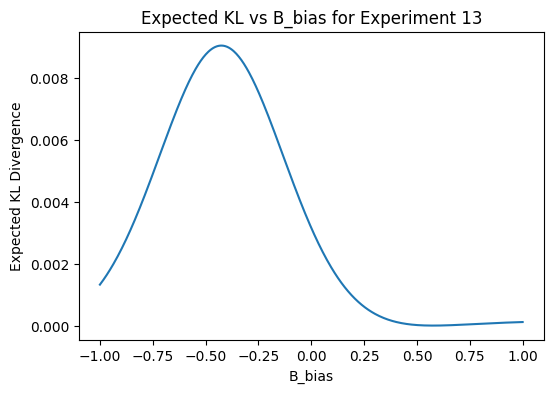

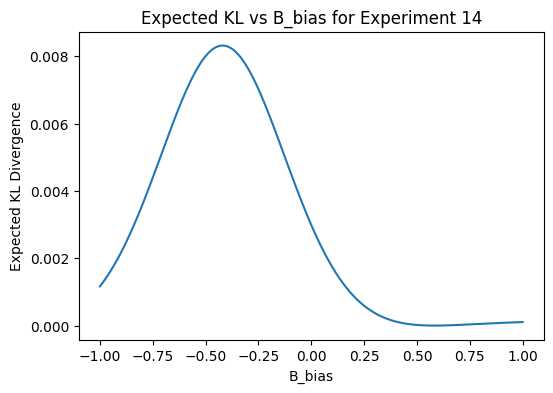

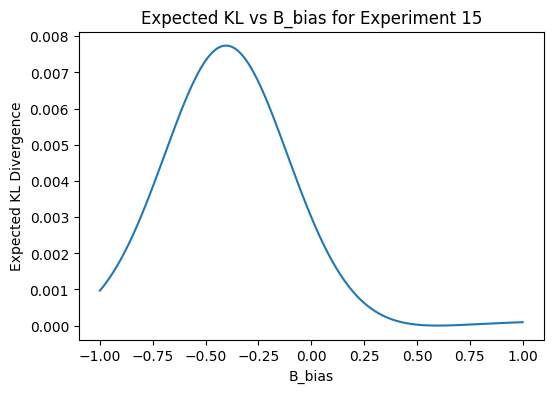

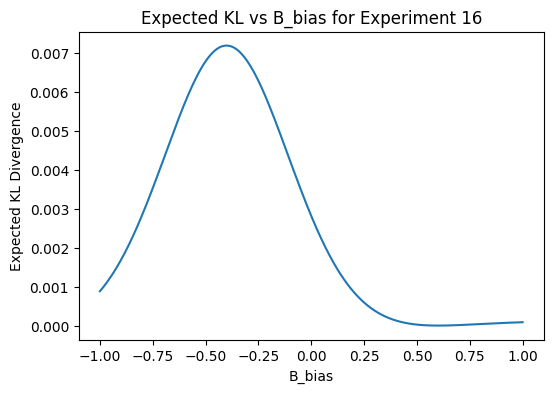

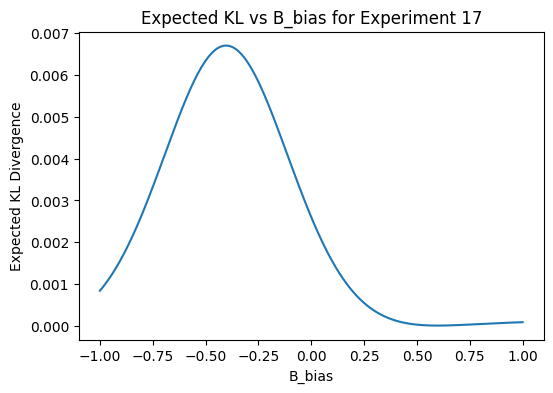

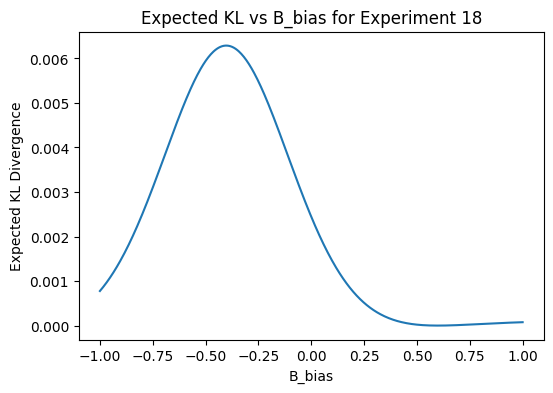

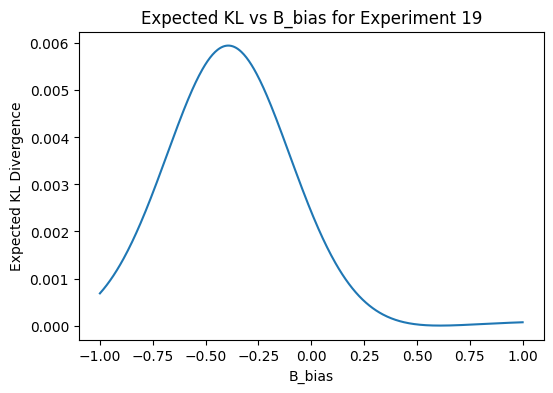

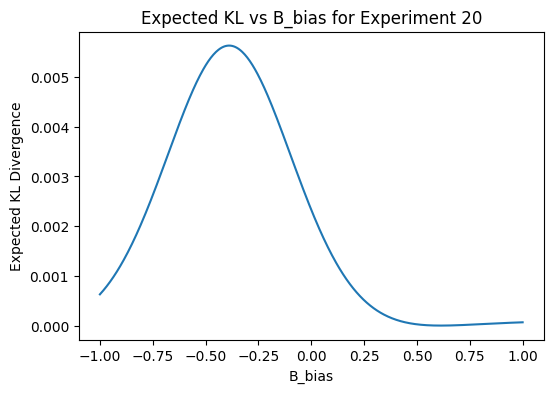

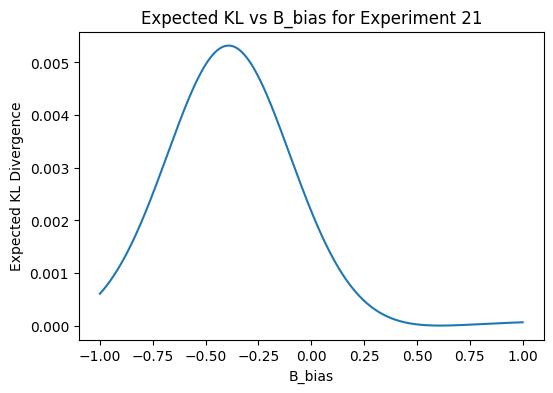

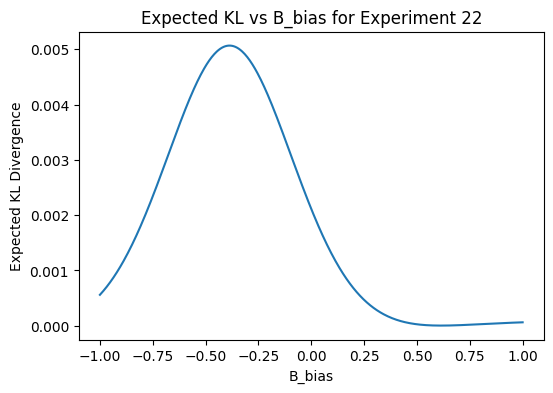

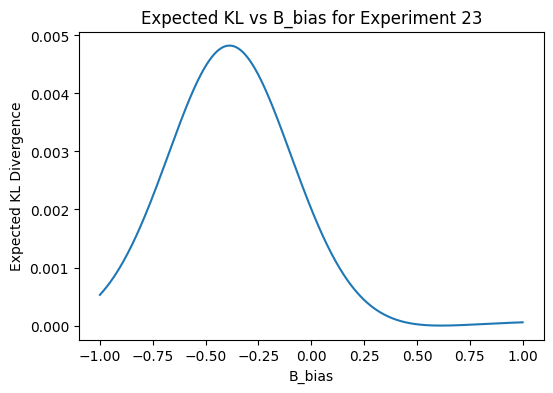

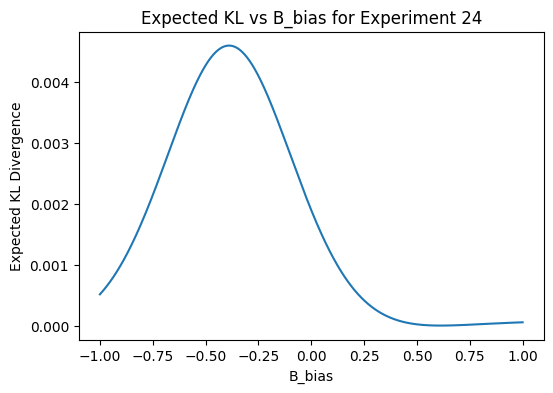

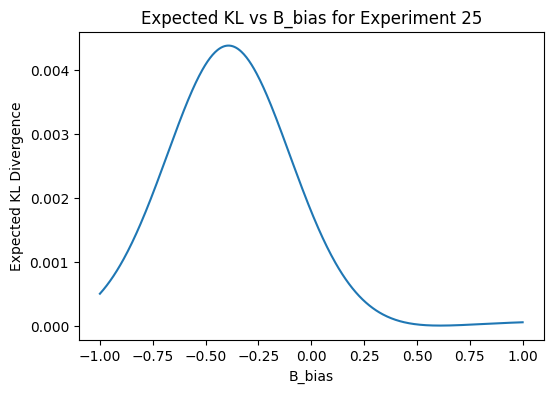

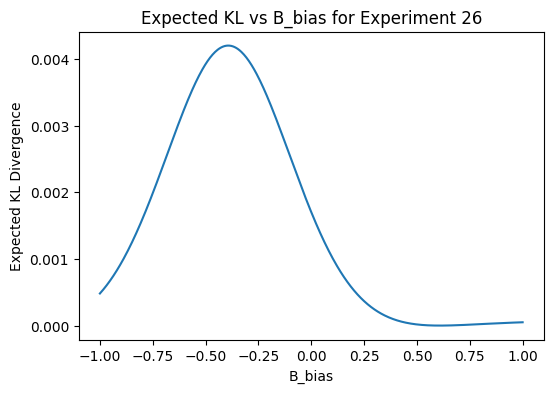

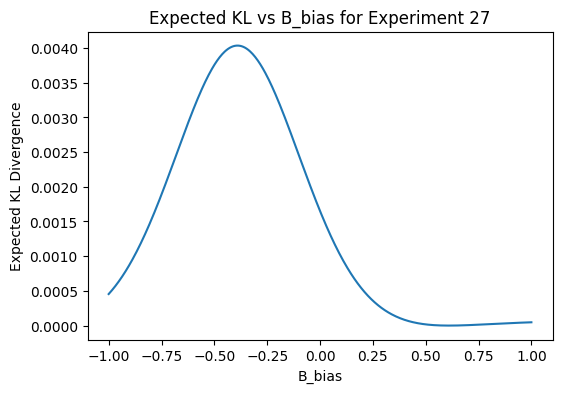

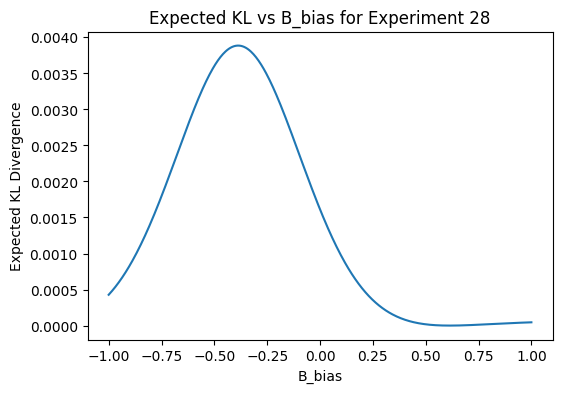

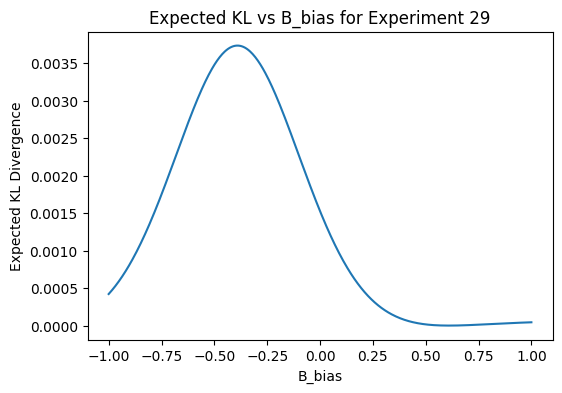

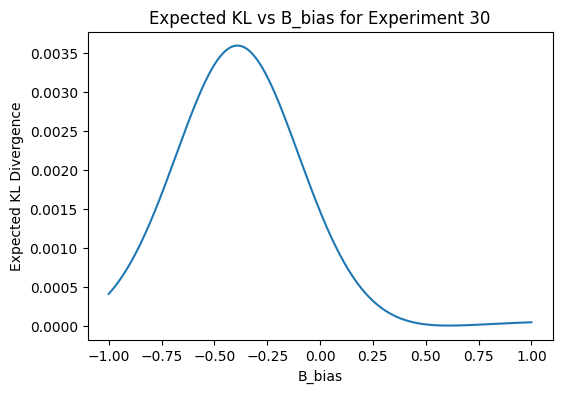

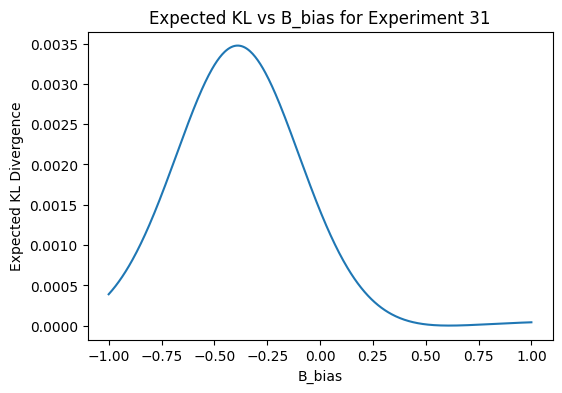

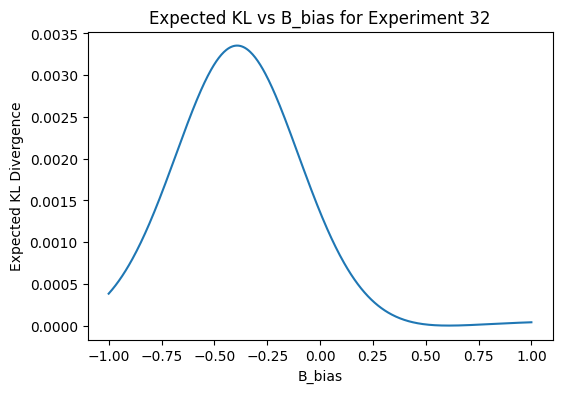

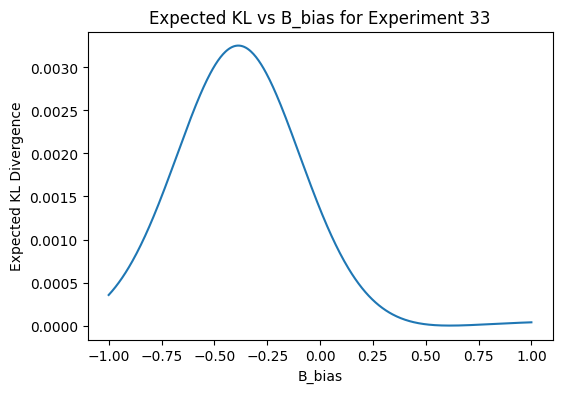

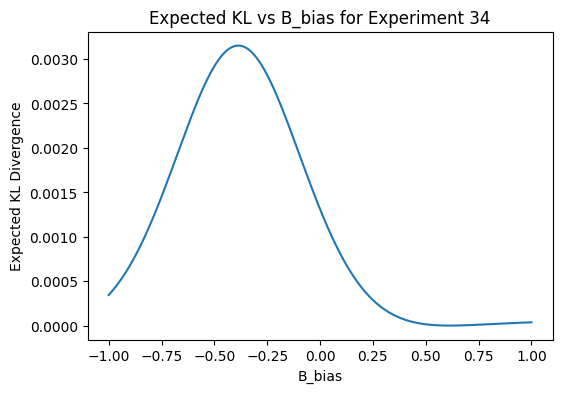

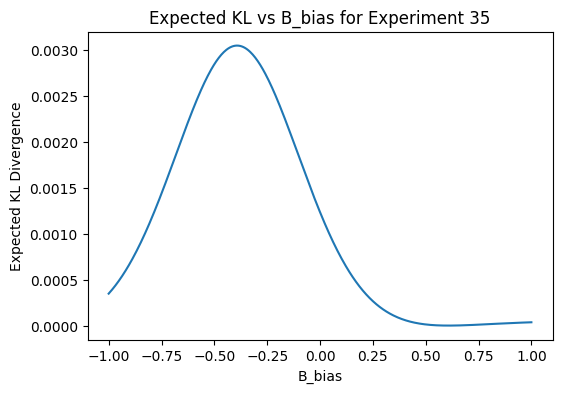

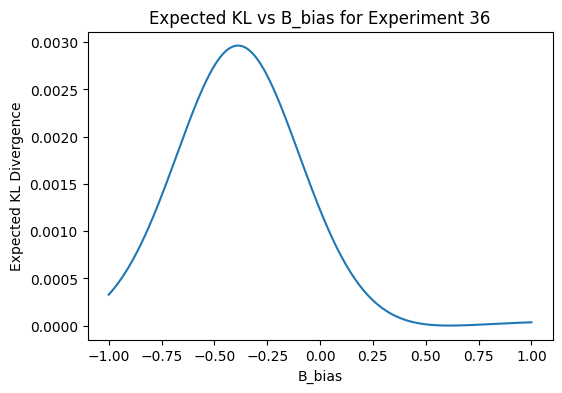

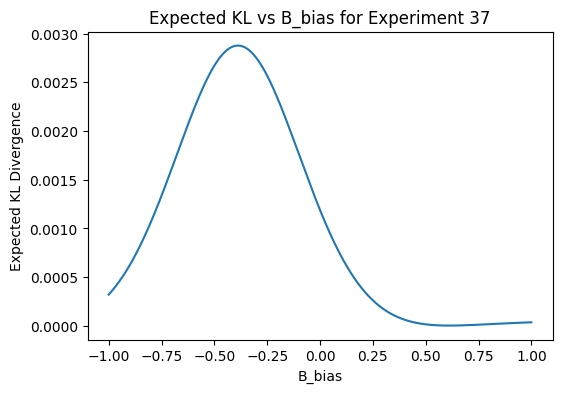

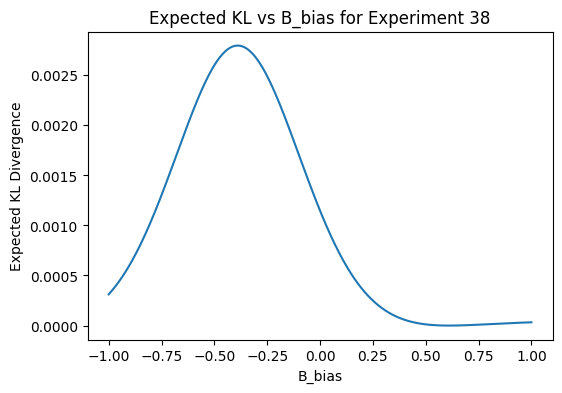

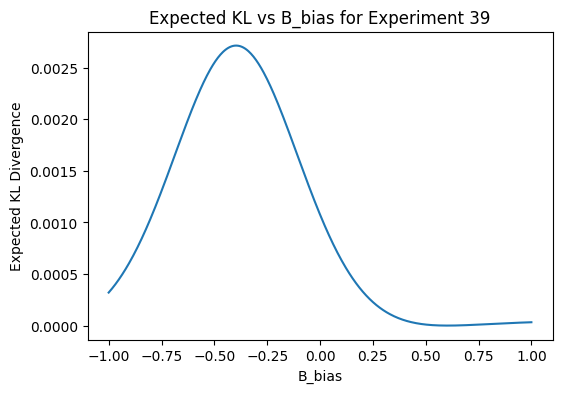

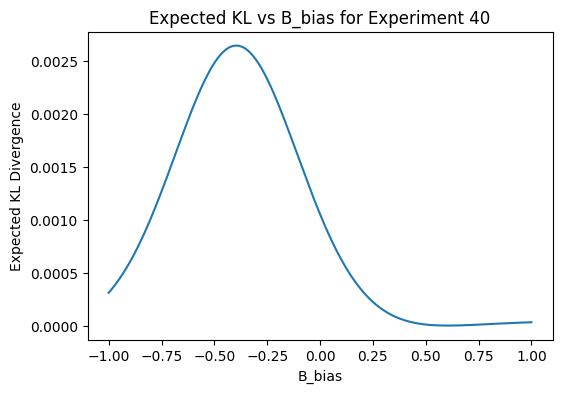

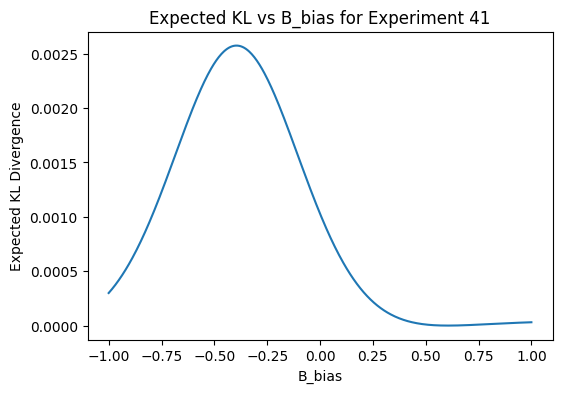

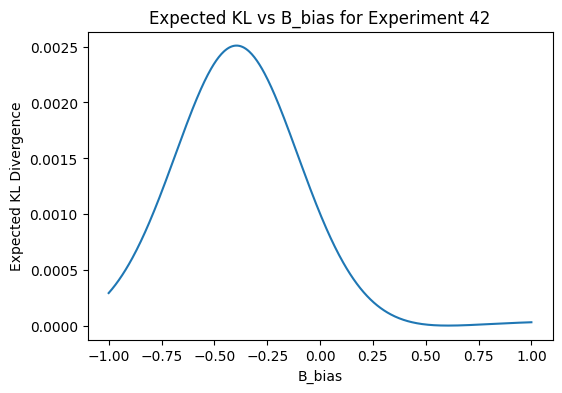

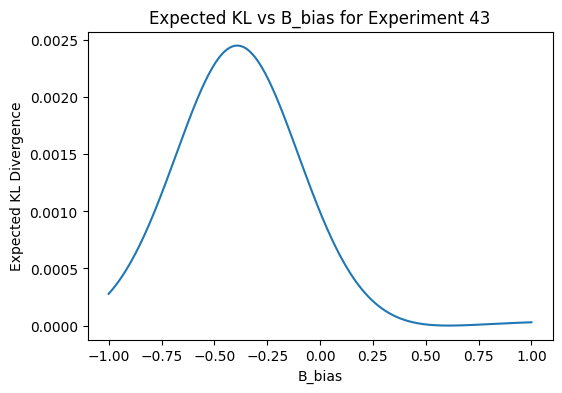

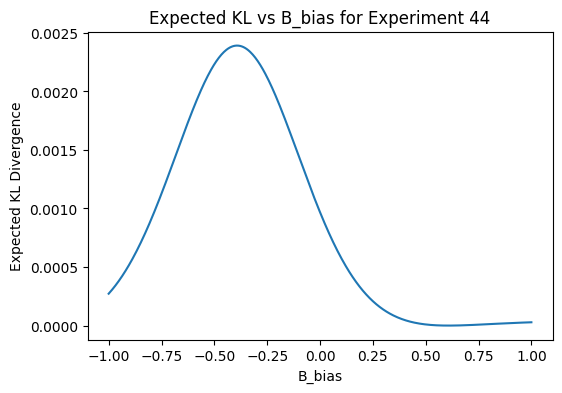

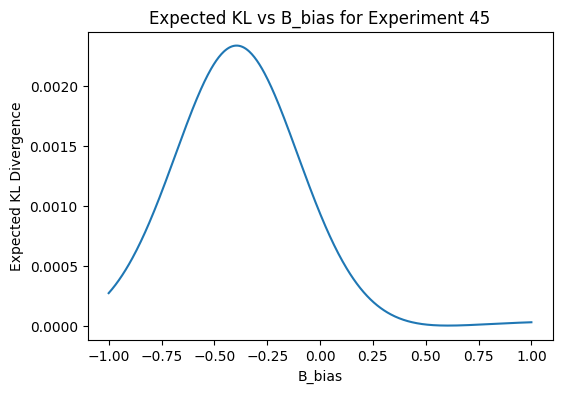

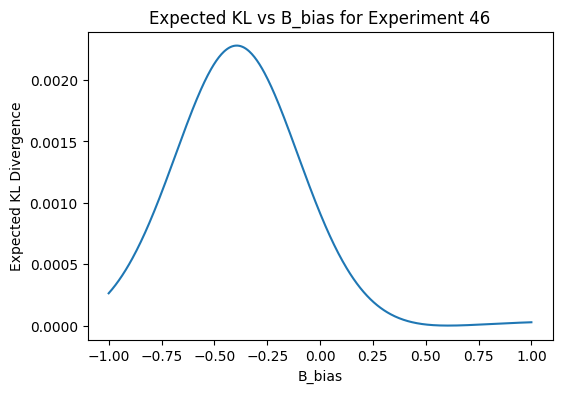

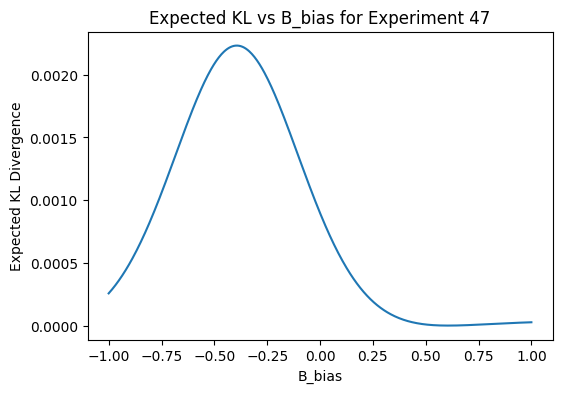

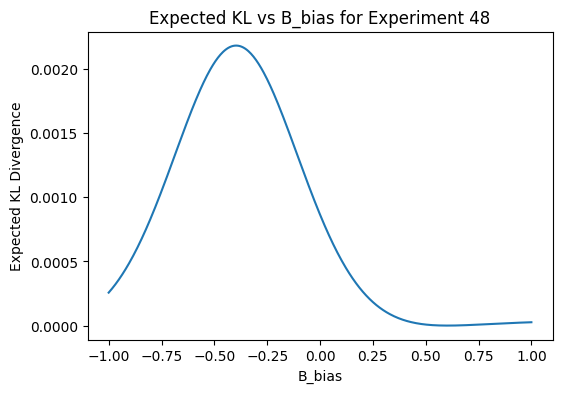

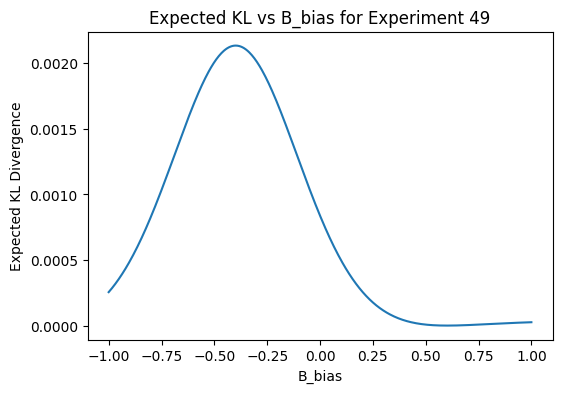

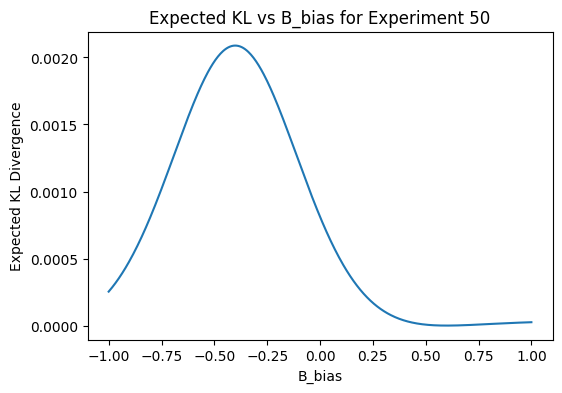

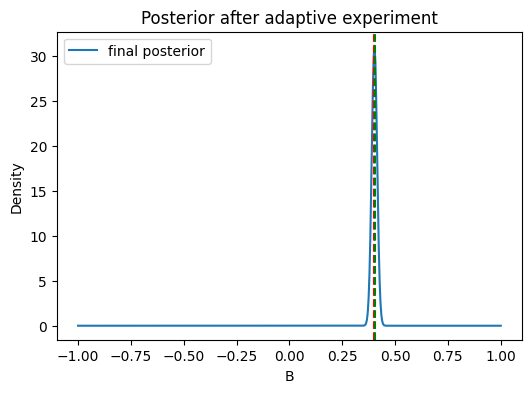

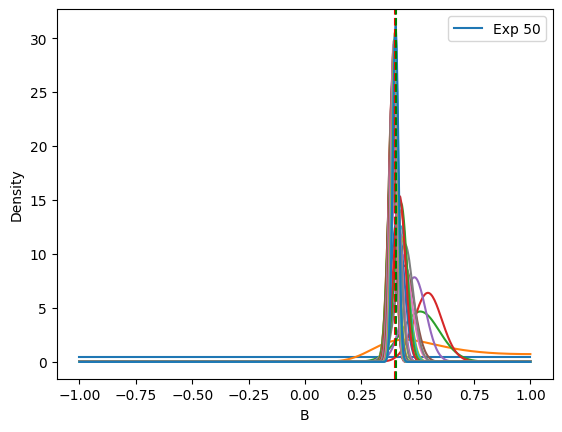

Mean: 0.40232480204843696 , Mode: 0.4028056112224448 , Varianc: 0.00016413927241120015
0.002004008016031981 : 0.7000633228658953 

-0.5871743486973948 : 0.30576213112828843 

-0.5150300601202406 : 0.08219481085775797 

-0.5470941883767535 : 0.04614492207321009 

-0.4829659318637275 : 0.031219466522295496 

-0.4388777555110221 : 0.024324029958786547 

-0.43086172344689383 : 0.019705858028371687 

-0.4428857715430862 : 0.016347384003205366 

-0.42284569138276556 : 0.014190433437730021 

-0.42284569138276556 : 0.012423999966805202 

-0.41082164328657317 : 0.011162007046768686 

-0.42284569138276556 : 0.00994853526901204 

-0.4268537074148297 : 0.009043435011026627 

-0.41883767535070143 : 0.008314384919784184 

-0.40280561122244496 : 0.0077404596224358475 

-0.40280561122244496 : 0.007195455488893352 

-0.40280561122244496 : 0.006703981711522431 

-0.40280561122244496 : 0.0062863745766200355 

-0.39078156312625256 : 0.005948166421377599 

-0.38677354709418843 : 0.0056300414407176235 

-0.

In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=50, B_true=B_true, sigma=0.2, B_range=(-1, 1), n_grid=500, candidates = cp.linspace(-1, 1, 500), Test = 1, Gamma = 0.01
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles = line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final,mode_final,variance_final = calculate_summary_stats(final_posterior, B_grid)
print('Mean:',mean_final,', Mode:', mode_final,', Varianc:', variance_final)
for i in range(len(biases)):
    print(biases[i],':', xpected_kl[i],'\n')

Test 3

Final posterior area (should be ~1): 1.000000


/tmp/ipython-input-258250029.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


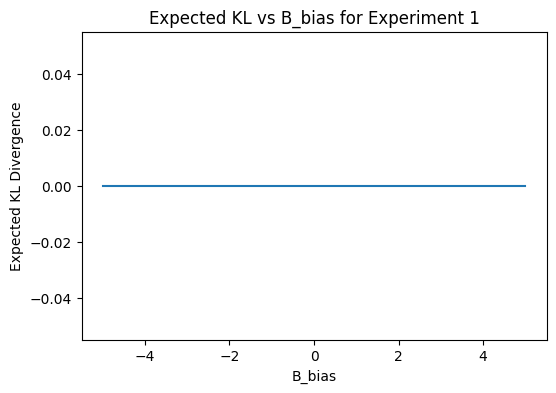

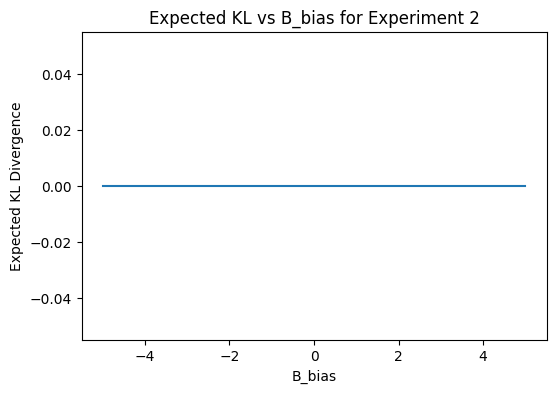

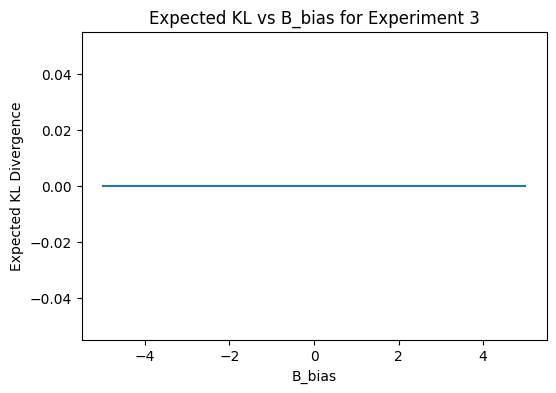

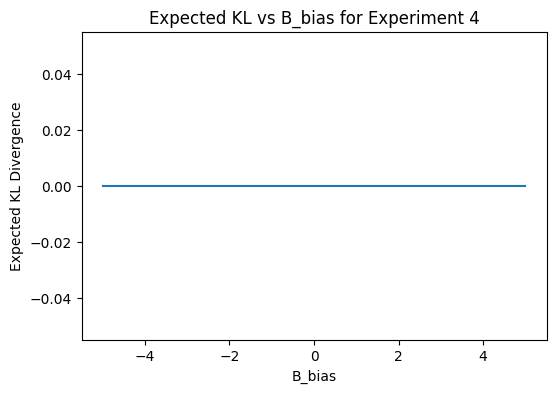

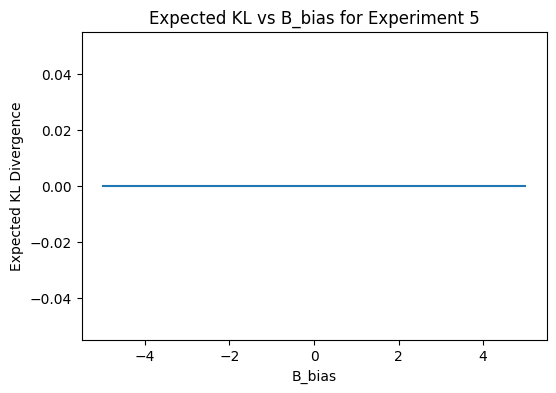

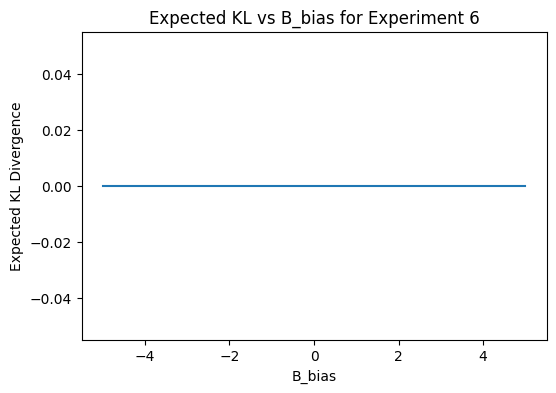

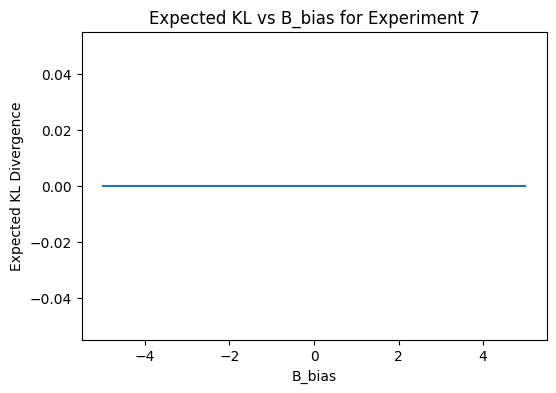

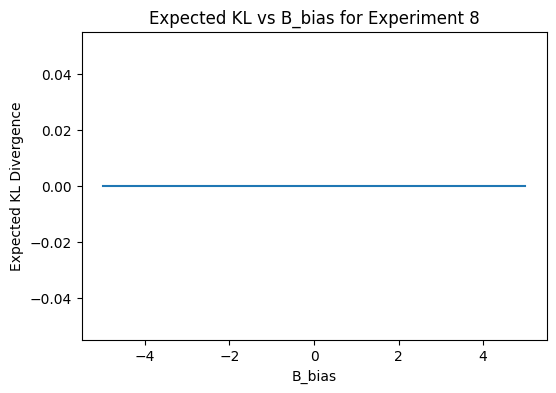

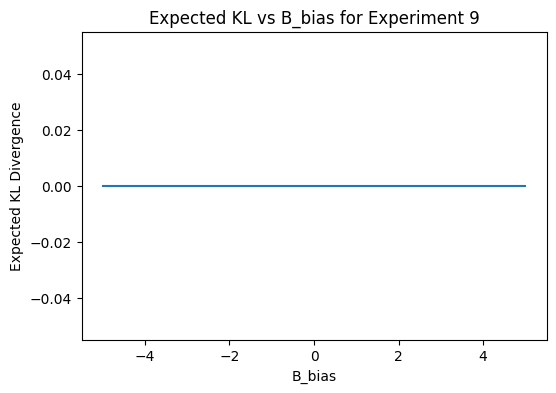

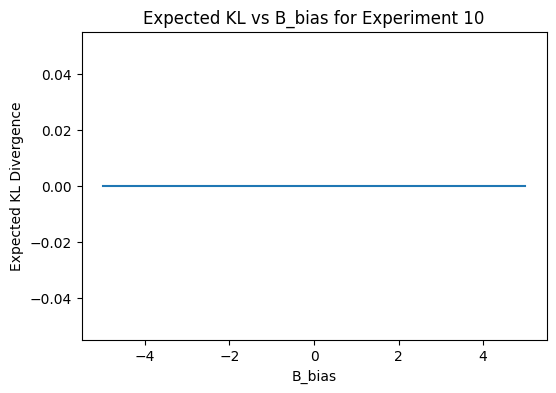

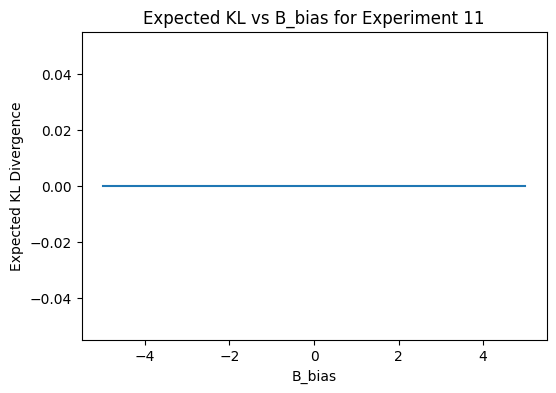

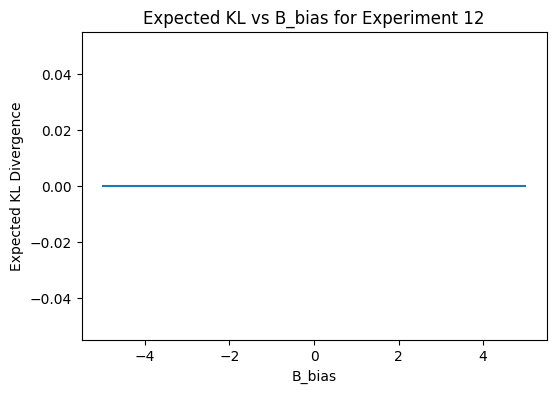

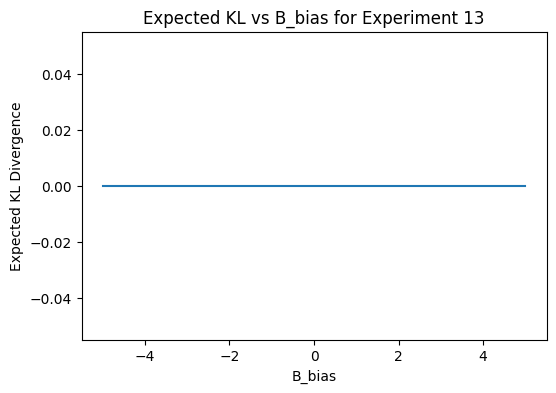

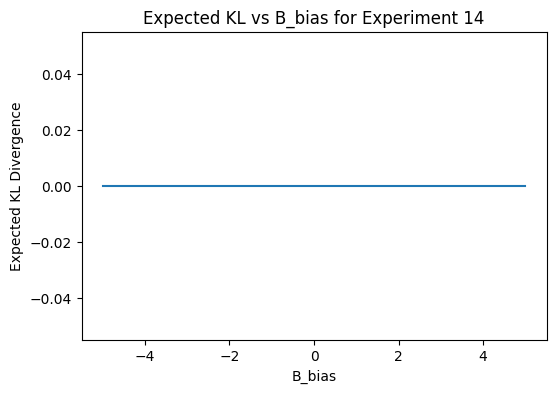

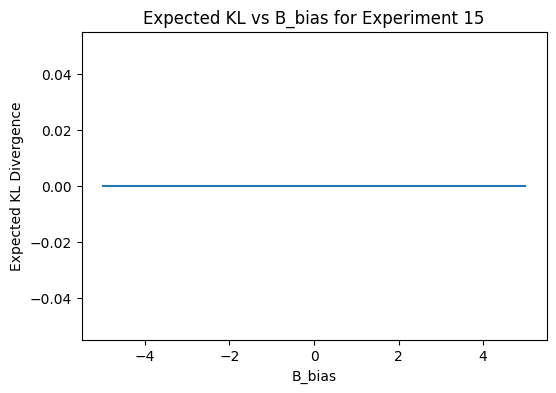

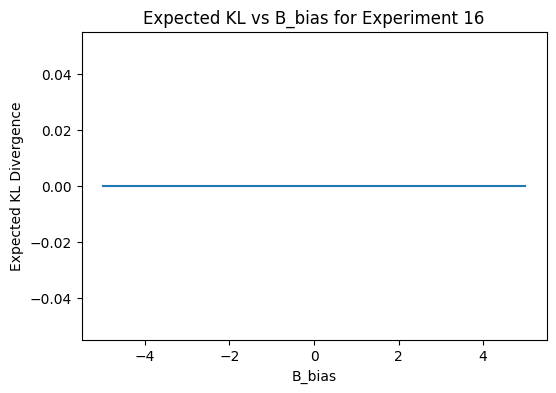

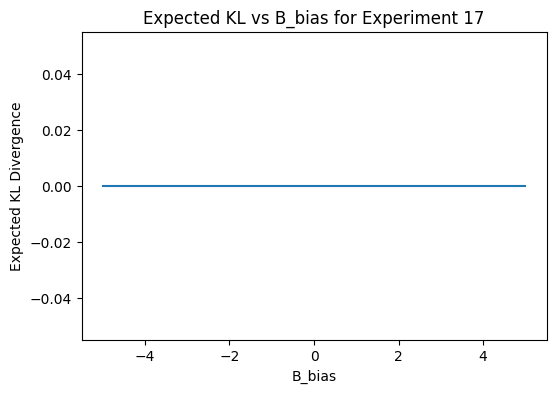

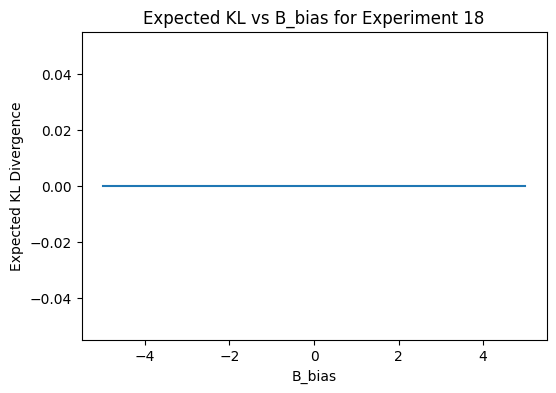

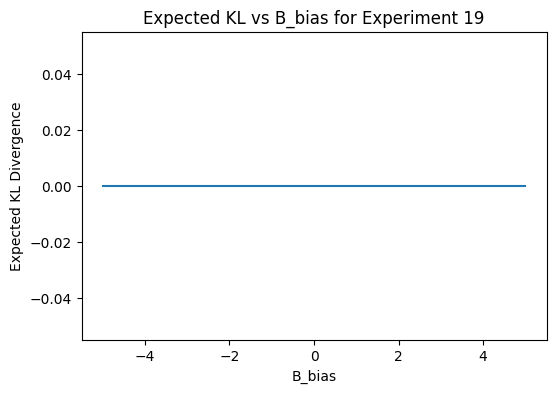

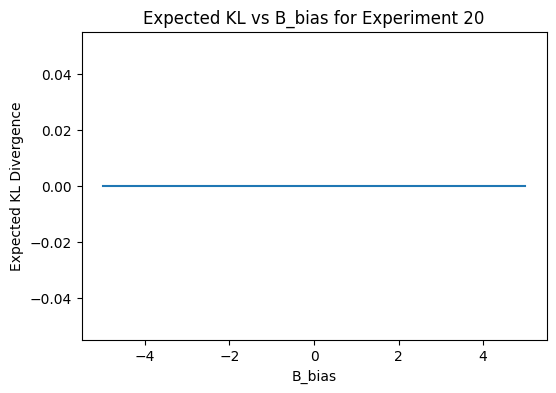

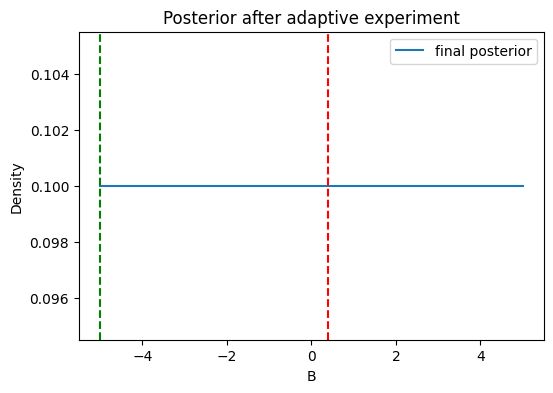

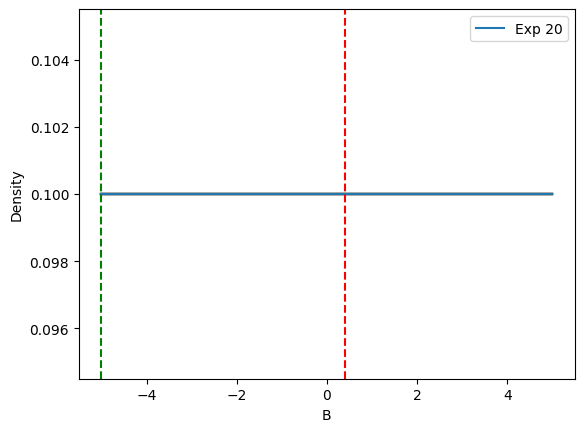

Mean: -2.896988204881268e-16 , Mode: -5.0 , Varianc: 8.333333333333336
-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 



In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20, B_true=B_true, Gamma=1.0, sigma=0, B_range=(-5, 5), n_grid=5000, candidates = cp.linspace(-5, 5, 5000), Test = 3
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles = line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final,mode_final,variance_final = calculate_summary_stats(final_posterior, B_grid)
print('Mean:',mean_final,', Mode:', mode_final,', Varianc:', variance_final)
for b in biases:
    print(b,'\n')

Test 4

In [ ]:
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20, B_true=B_true, Gamma=1.0, sigma=0.1, B_range=(-1, 1), n_grid=500, candidates = cp.linspace(-1, 1, 500), Test = 4
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles = line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final,mode_final,variance_final = calculate_summary_stats(final_posterior, B_grid)
print('Mean:',mean_final,', Mode:', mode_final,', Varianc:', variance_final)
for i in range(len(biases)):
    print(biases[i],':', xpected_kl[i],'\n')

Test 5

In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20, B_true=B_true, Gamma=1.0, sigma=0.05, B_range=(-1, 1), n_grid=5000, candidates = cp.linspace(-1, 1, 5000), Test = 5
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles = line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final,mode_final,variance_final = calculate_summary_stats(final_posterior, B_grid)
print('Mean:',mean_final,', Mode:', mode_final,', Varianc:', variance_final)
for b in biases:
    print(b,'\n')

  Test 6

In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20, B_true=B_true, Gamma=1.0, sigma=0.05, B_range=(-1, 1), n_grid=500, candidates = cp.linspace(-1, 1, 500), Test = 6
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles = line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final,mode_final,variance_final = calculate_summary_stats(final_posterior, B_grid)
print('Mean:',mean_final,', Mode:', mode_final,', Varianc:', variance_final)
for b in biases:
    print(b,'\n')

In [ ]:
# TODO: Parallelise
# TODO: compare with frequentist zero crossing approach: give quantitative estimate of:
# 1. amount of readings required for both
# 2. accuracy of estimate for both
# 3. inference time for both